In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# Load datasets
operators = pd.read_csv('operator_accounts.csv', parse_dates=['join_date', 'churn_date'])
revenue = pd.read_csv('operator_revenue_monthly.csv')

print("Operators shape:", operators.shape)
print("Revenue shape:", revenue.shape)

Operators shape: (80, 14)
Revenue shape: (1420, 13)


In [3]:
# Quick look at operator_accounts
operators.head()

,operator_id,operator_name,country,platform_type,plan_tier,monthly_fee_usd,join_date,is_active,churn_date,churn_reason,account_manager,games_enabled,sports_markets_enabled,payment_methods_count
0,OP0001,Brand_001,AU,Casino,Starter,2500,2023-10-17,1,NaT,NaN,AM02,5743,0,7
1,OP0002,Brand_002,NG,Casino,Starter,2500,2023-07-13,1,NaT,NaN,AM04,2105,0,6
2,OP0003,Brand_003,CA,Both,Starter,2500,2023-09-09,1,NaT,NaN,AM07,2005,0,5
3,OP0004,Brand_004,IN,Casino,Starter,2500,2023-08-27,1,NaT,NaN,AM07,2987,0,4
4,OP0005,Brand_005,ZA,Sportsbook,Starter,2500,2022-06-09,1,NaT,NaN,AM02,3140,0,8


In [88]:
operators.describe()

,monthly_fee_usd,join_date,is_active,churn_date,games_enabled,sports_markets_enabled,payment_methods_count,end_date,tenure_months
count,80.000000,80,80.000000,16,80.000000,80.000000,80.000000,80,80.000000
mean,6743.750000,2023-03-09 00:54:00,0.800000,2024-02-17 01:30:00,4102.687500,10.375000,5.237500,2024-10-28 09:54:00,19.980000
min,2500.000000,2022-01-20 00:00:00,0.000000,2023-06-21 00:00:00,213.000000,0.000000,2.000000,2023-06-21 00:00:00,-10.500000
25%,2500.000000,2022-07-30 12:00:00,1.000000,2023-11-10 06:00:00,2116.250000,0.000000,4.000000,2024-12-31 00:00:00,13.125000
50%,2500.000000,2023-03-19 00:00:00,1.000000,2024-02-04 00:00:00,4050.500000,0.000000,5.500000,2024-12-31 00:00:00,20.550000
75%,7500.000000,2023-09-02 06:00:00,1.000000,2024-04-30 00:00:00,6096.000000,17.000000,7.000000,2024-12-31 00:00:00,27.000000
max,22000.000000,2024-06-01 00:00:00,1.000000,2024-11-28 00:00:00,7982.000000,50.000000,8.000000,2024-12-31 00:00:00,35.200000
std,6528.415857,NaN,0.402524,NaN,2443.568808,15.827692,1.956772,NaN,9.197184


In [4]:
# Check data types and nulls
operators.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   operator_id             80 non-null     object        
 1   operator_name           80 non-null     object        
 2   country                 80 non-null     object        
 3   platform_type           80 non-null     object        
 4   plan_tier               80 non-null     object        
 5   monthly_fee_usd         80 non-null     int64         
 6   join_date               80 non-null     datetime64[ns]
 7   is_active               80 non-null     int64         
 8   churn_date              16 non-null     datetime64[ns]
 9   churn_reason            16 non-null     object        
 10  account_manager         80 non-null     object        
 11  games_enabled           80 non-null     int64         
 12  sports_markets_enabled  80 non-null     int64       

In [5]:
# Quick look at operator_revenue_monthly
revenue.head()

,operator_id,month,plan_tier,casino_ggr_usd,sports_ggr_usd,total_ggr_usd,net_software_revenue_usd,monthly_license_fee_usd,active_players,new_registrations,deposits_count,total_deposits_usd,bonus_cost_usd
0,OP0001,2023-10,Starter,6899.20,3714.95,10614.15,1383.46,2500,1161,92,521,107796.28,543.85
1,OP0001,2023-11,Starter,6149.73,3311.40,9461.13,1872.16,2500,240,33,122,22890.10,685.95
2,OP0001,2023-12,Starter,6482.46,3490.55,9973.01,1365.56,2500,1186,135,769,89827.99,970.61
3,OP0001,2024-01,Starter,7575.49,4079.11,11654.60,1981.52,2500,737,103,505,55043.61,546.44
4,OP0001,2024-02,Starter,7393.78,3981.26,11375.04,1553.90,2500,1368,126,894,115528.97,894.40


In [89]:
revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1420 entries, 0 to 1419
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   operator_id               1420 non-null   object 
 1   month                     1420 non-null   object 
 2   plan_tier                 1420 non-null   object 
 3   casino_ggr_usd            1420 non-null   float64
 4   sports_ggr_usd            1420 non-null   float64
 5   total_ggr_usd             1420 non-null   float64
 6   net_software_revenue_usd  1420 non-null   float64
 7   monthly_license_fee_usd   1420 non-null   int64  
 8   active_players            1420 non-null   int64  
 9   new_registrations         1420 non-null   int64  
 10  deposits_count            1420 non-null   int64  
 11  total_deposits_usd        1420 non-null   float64
 12  bonus_cost_usd            1420 non-null   float64
 13  casino_pct                1420 non-null   float64
 14  sports_p

In [90]:
# Quick look at operator_revenue_monthly
revenue.isnull().sum()

operator_id                 0
month                       0
plan_tier                   0
casino_ggr_usd              0
sports_ggr_usd              0
total_ggr_usd               0
net_software_revenue_usd    0
monthly_license_fee_usd     0
active_players              0
new_registrations           0
deposits_count              0
total_deposits_usd          0
bonus_cost_usd              0
casino_pct                  0
sports_pct                  0
bonus_pct_of_ggr            0
dtype: int64

In [91]:
revenue.describe()

,casino_ggr_usd,sports_ggr_usd,total_ggr_usd,net_software_revenue_usd,monthly_license_fee_usd,active_players,new_registrations,deposits_count,total_deposits_usd,bonus_cost_usd,casino_pct,sports_pct,bonus_pct_of_ggr
count,1420.000000,1420.000000,1.420000e+03,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000
mean,79504.954796,42810.360077,1.223153e+05,20621.688951,6835.915493,1557.165493,192.771831,783.231690,108820.609408,8638.368887,65.000000,35.000000,6.998599
std,111732.424977,60163.613305,1.718960e+05,29534.589473,6475.832902,1329.808562,189.137760,713.839554,110059.961278,12689.856677,0.000013,0.000013,1.703575
min,4516.590000,2432.010000,6.948600e+03,994.660000,2500.000000,16.000000,1.000000,7.000000,489.770000,309.370000,64.999938,34.999938,4.000255
25%,14141.870000,7614.847500,2.175672e+04,3397.645000,2500.000000,553.000000,61.000000,257.750000,32345.287500,1378.997500,64.999997,34.999996,5.561141
50%,26229.970000,14123.825000,4.035379e+04,7043.165000,2500.000000,1122.500000,127.000000,526.500000,71009.095000,2893.880000,65.000000,35.000000,6.992285
75%,100259.560000,53985.915000,1.542455e+05,25753.037500,7500.000000,2322.500000,250.250000,1075.750000,140125.632500,10382.090000,65.000003,35.000003,8.481984
max,653409.790000,351836.040000,1.005246e+06,202124.830000,22000.000000,4997.000000,952.000000,3323.000000,589103.570000,87469.990000,65.000067,35.000067,9.999889


In [92]:
revenue.query

<bound method DataFrame.query of      operator_id    month plan_tier  casino_ggr_usd  sports_ggr_usd  \
0         OP0001  2023-10   Starter         6899.20         3714.95   
1         OP0001  2023-11   Starter         6149.73         3311.40   
2         OP0001  2023-12   Starter         6482.46         3490.55   
3         OP0001  2024-01   Starter         7575.49         4079.11   
4         OP0001  2024-02   Starter         7393.78         3981.26   
...          ...      ...       ...             ...             ...   
1415      OP0080  2024-08    Growth        90308.02        48627.39   
1416      OP0080  2024-09    Growth       116169.85        62552.99   
1417      OP0080  2024-10    Growth       139874.05        75316.80   
1418      OP0080  2024-11    Growth       118680.37        63904.82   
1419      OP0080  2024-12    Growth        86690.92        46679.72   

      total_ggr_usd  net_software_revenue_usd  monthly_license_fee_usd  \
0          10614.15                   13

### Q1. How many operators are active vs. churned? What's the overall churn rate?

In [7]:
churn_counts = operators['is_active'].value_counts()
churn_counts.index = churn_counts.index.map({1: 'Active', 0: 'Churned'})
print(churn_counts)

churn_rate = (operators['is_active'] == 0).mean() * 100
print(f"\nOverall churn rate: {churn_rate:.2f}%")

is_active
Active     64
Churned    16
Name: count, dtype: int64

Overall churn rate: 20.00%


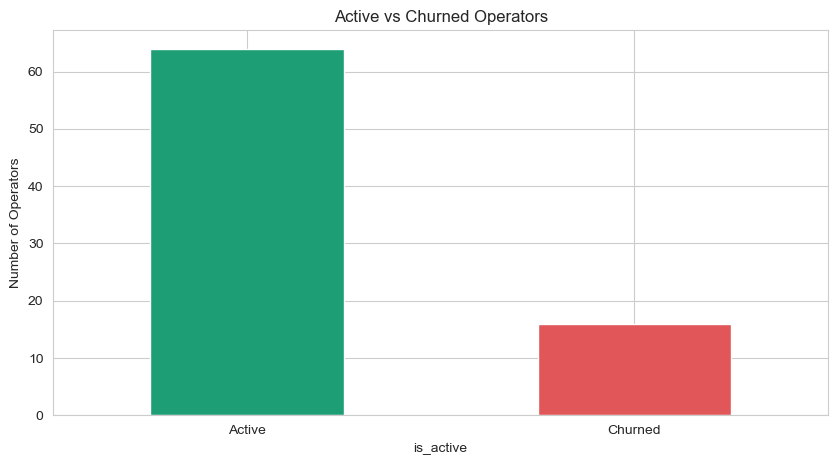

In [8]:
# Visualize
churn_counts.plot(kind='bar', color=['#1D9E75', '#E15759'])
plt.title('Active vs Churned Operators')
plt.ylabel('Number of Operators')
plt.xticks(rotation=0)
plt.show()

### Q2. Churn rate by `plan_tier` — are Starter accounts churning more than Enterprise?

In [9]:
churn_by_tier = operators.groupby('plan_tier')['is_active'].agg(
    total='count',
    active='sum'
)
churn_by_tier['churned'] = churn_by_tier['total'] - churn_by_tier['active']
churn_by_tier['churn_rate_pct'] = (churn_by_tier['churned'] / churn_by_tier['total'] * 100).round(2)
churn_by_tier

,total,active,churned,churn_rate_pct
plan_tier,,,,
Enterprise,11,8,3,27.27
Growth,25,22,3,12.00
Starter,44,34,10,22.73


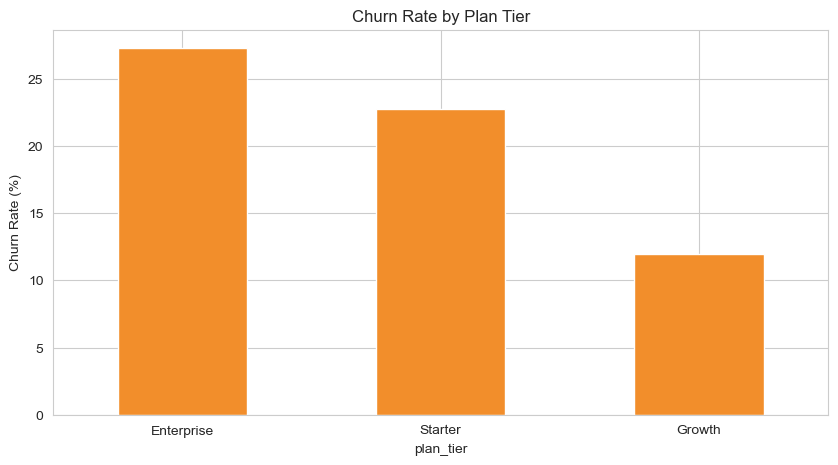

In [10]:
# Visualize
churn_by_tier['churn_rate_pct'].sort_values(ascending=False).plot(kind='bar', color='#F28E2B')
plt.title('Churn Rate by Plan Tier')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

### Q3. Churn rate by `country` — any geographic concentration?

In [11]:
churn_by_country = operators.groupby('country')['is_active'].agg(
    total='count',
    active='sum'
)
churn_by_country['churned'] = churn_by_country['total'] - churn_by_country['active']
churn_by_country['churn_rate_pct'] = (churn_by_country['churned'] / churn_by_country['total'] * 100).round(2)
churn_by_country.sort_values('churn_rate_pct', ascending=False)

,total,active,churned,churn_rate_pct
country,,,,
PH,8,4,4,50.00
GB,9,6,3,33.33
ZA,6,4,2,33.33
AU,9,7,2,22.22
DE,9,7,2,22.22
IN,6,5,1,16.67
KE,6,5,1,16.67
NG,8,7,1,12.50
BR,9,9,0,0.00


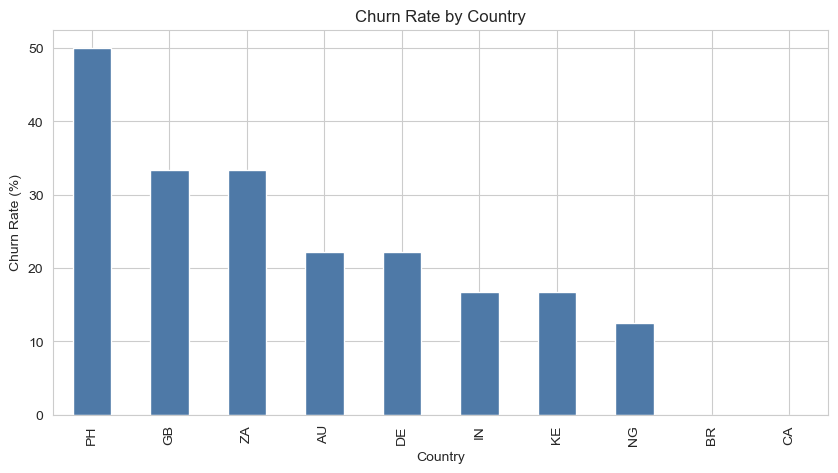

In [12]:
# Visualize
churn_by_country['churn_rate_pct'].sort_values(ascending=False).plot(kind='bar', color='#4E79A7')
plt.title('Churn Rate by Country')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Country')
plt.show()

### Q4. Distribution of `monthly_fee_usd`, `games_enabled`, `sports_markets_enabled` — do churned operators look different from day one?

In [13]:
# Compare distributions: Active vs Churned
features = ['monthly_fee_usd', 'games_enabled', 'sports_markets_enabled', 'payment_methods_count']

for col in features:
    print(f"\n--- {col} ---")
    print(operators.groupby('is_active')[col].describe()[['mean', '50%', 'std']])


--- monthly_fee_usd ---
              mean     50%          std
is_active                              
0          7093.75  2500.0  7651.184549
1          6656.25  2500.0  6282.297502

--- games_enabled ---
                  mean     50%          std
is_active                                  
0          4037.625000  3814.5  2599.976381
1          4118.953125  4050.5  2424.178581

--- sports_markets_enabled ---
               mean  50%        std
is_active                          
0           8.25000  0.0  14.812157
1          10.90625  0.0  16.138998

--- payment_methods_count ---
             mean  50%       std
is_active                       
0          6.1875  7.0  1.600781
1          5.0000  5.0  1.976047


C:\Users\hp\AppData\Local\Temp\ipykernel_5652\3425898367.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Churned', 'Active'])
C:\Users\hp\AppData\Local\Temp\ipykernel_5652\3425898367.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Churned', 'Active'])
C:\Users\hp\AppData\Local\Temp\ipykernel_5652\3425898367.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Churned', 'Active'])
C:\Users\hp\AppData\Local\Temp\ipykernel_5652\3425898367.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Churned', 'Active'])


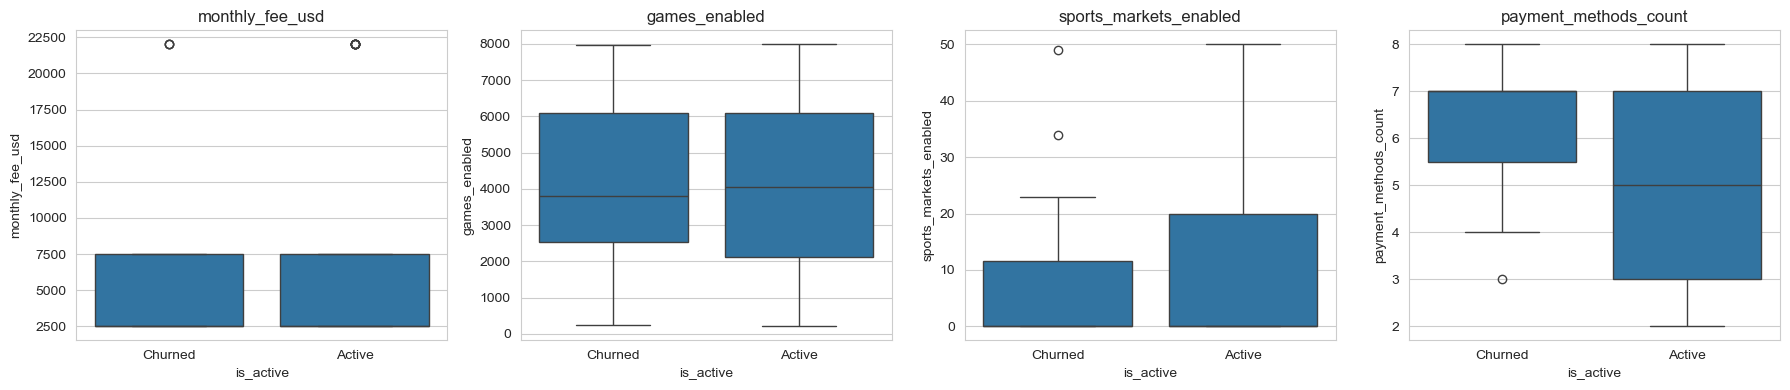

In [14]:
# Visualize as boxplots
fig, axes = plt.subplots(1, len(features), figsize=(18, 4))

for ax, col in zip(axes, features):
    sns.boxplot(data=operators, x='is_active', y=col, ax=ax)
    ax.set_xticklabels(['Churned', 'Active'])
    ax.set_title(col)

plt.tight_layout()
plt.show()

### Q5. `churn_reason` breakdown — what's the leading cause of churn?

In [15]:
churn_reasons = operators[operators['is_active'] == 0]['churn_reason'].value_counts()
churn_reasons

churn_reason
Payment Issue    7
Unknown          3
Competitor       3
Inactivity       2
Regulatory       1
Name: count, dtype: int64

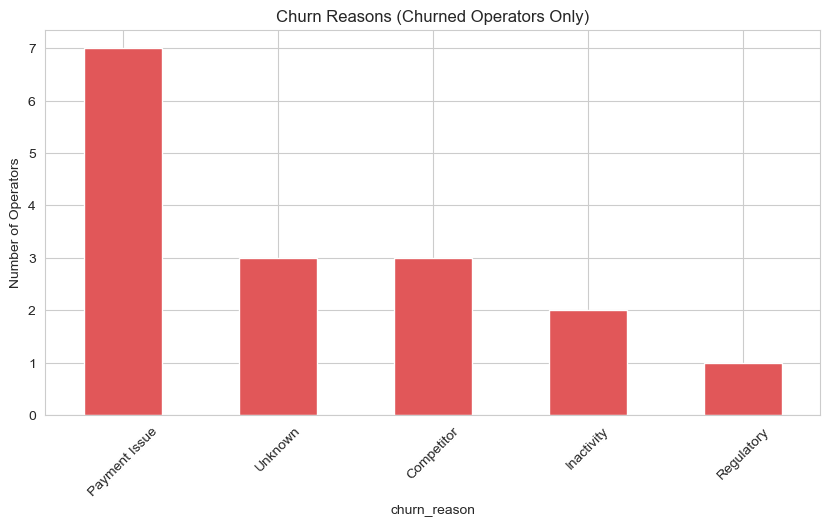

In [16]:
# Visualize
churn_reasons.plot(kind='bar', color='#E15759')
plt.title('Churn Reasons (Churned Operators Only)')
plt.ylabel('Number of Operators')
plt.xticks(rotation=45)
plt.show()

### Q6. Tenure analysis — how long do operators last before churning? (`churn_date - join_date`)

In [18]:
# Calculate tenure in months for ALL operators
# For active operators, use today's date as reference; for churned, use churn_date
reference_date = pd.Timestamp('2024-12-31')

operators['end_date'] = operators['churn_date'].fillna(reference_date)
operators['tenure_months'] = (
    (operators['end_date'] - operators['join_date']) / pd.Timedelta(days=30)
).round(1)

operators[['operator_id', 'join_date', 'churn_date', 'is_active', 'tenure_months']].head()

,operator_id,join_date,churn_date,is_active,tenure_months
0,OP0001,2023-10-17,NaT,1,14.7
1,OP0002,2023-07-13,NaT,1,17.9
2,OP0003,2023-09-09,NaT,1,16.0
3,OP0004,2023-08-27,NaT,1,16.4
4,OP0005,2022-06-09,NaT,1,31.2


In [19]:
# Compare tenure: Active vs Churned
operators.groupby('is_active')['tenure_months'].describe()[['mean', '50%', 'min', 'max']]

,mean,50%,min,max
is_active,,,,
0,13.812500,12.4,-10.5,32.7
1,21.521875,21.2,7.1,35.2


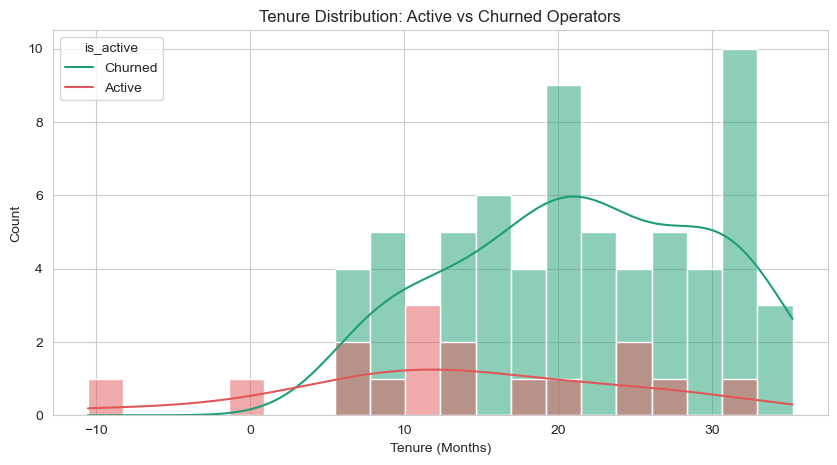

In [20]:
# Visualize tenure distribution
sns.histplot(data=operators, x='tenure_months', hue='is_active', bins=20, kde=True,
              palette={1: '#1D9E75', 0: '#E15759'})
plt.title('Tenure Distribution: Active vs Churned Operators')
plt.xlabel('Tenure (Months)')
plt.legend(title='is_active', labels=['Churned', 'Active'])
plt.show()

### Q7. Plot total GGR trend month-over-month across all operators — is the platform growing overall?

In [22]:
# Aggregate total GGR by month across all operators
monthly_ggr = revenue.groupby('month')['total_ggr_usd'].sum().reset_index()
monthly_ggr = monthly_ggr.sort_values('month')
monthly_ggr.head()

,month,total_ggr_usd
0,2023-01,3710311.64
1,2023-02,4790435.41
2,2023-03,5693675.25
3,2023-04,6483793.76
4,2023-05,6547848.17


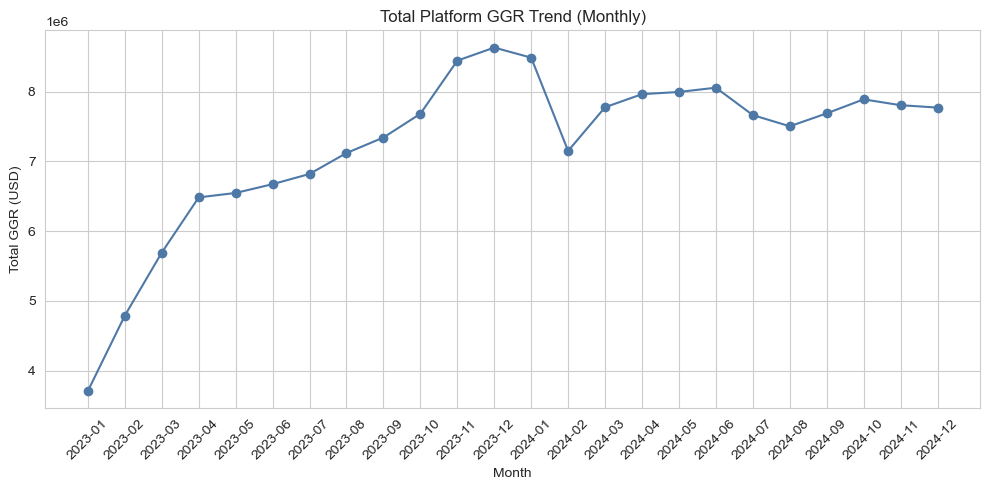

In [23]:
# Visualize
plt.plot(monthly_ggr['month'], monthly_ggr['total_ggr_usd'], marker='o', color='#4E79A7')
plt.title('Total Platform GGR Trend (Monthly)')
plt.ylabel('Total GGR (USD)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Q8. For each operator, compare GGR in last 3 months before churn vs. first 3 months. Declining revenue is usually the #1 churn predictor.

In [24]:
# Get only churned operators
churned_ops = operators[operators['is_active'] == 0]['operator_id'].tolist()

results = []
for op_id in churned_ops:
    op_revenue = revenue[revenue['operator_id'] == op_id].sort_values('month')
    if len(op_revenue) < 4:
        continue  # skip operators with too little history
    first_3 = op_revenue.head(3)['total_ggr_usd'].mean()
    last_3 = op_revenue.tail(3)['total_ggr_usd'].mean()
    pct_change = ((last_3 - first_3) / first_3) * 100
    results.append({
        'operator_id': op_id,
        'first_3m_avg_ggr': round(first_3, 2),
        'last_3m_avg_ggr': round(last_3, 2),
        'pct_change': round(pct_change, 2)
    })

ggr_trend_df = pd.DataFrame(results)
ggr_trend_df.head(10)

,operator_id,first_3m_avg_ggr,last_3m_avg_ggr,pct_change
0,OP0007,29868.66,30114.61,0.82
1,OP0008,76167.02,84355.24,10.75
2,OP0012,27033.61,27220.01,0.69
3,OP0018,41574.61,33642.28,-19.08
4,OP0020,39290.46,39981.51,1.76
5,OP0021,11052.03,11205.44,1.39
6,OP0031,144930.16,136805.49,-5.61
7,OP0039,43890.75,41459.27,-5.54
8,OP0040,189794.66,235441.96,24.05
9,OP0047,562603.64,485162.83,-13.76


In [25]:
# Summary: how many churned operators show declining GGR before churn?
declining = (ggr_trend_df['pct_change'] < 0).sum()
total = len(ggr_trend_df)
print(f"{declining} out of {total} churned operators ({declining/total*100:.1f}%) "
      f"show declining GGR in their last 3 months vs. first 3 months")

6 out of 14 churned operators (42.9%) show declining GGR in their last 3 months vs. first 3 months


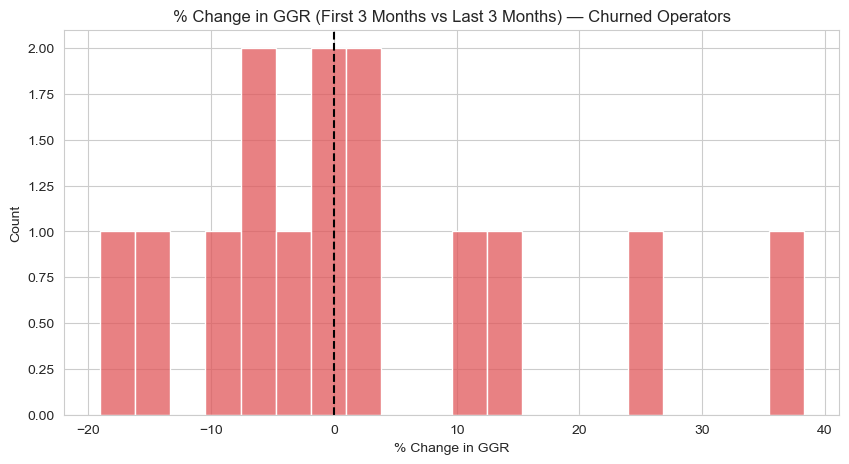

In [26]:
# Visualize distribution of % change
sns.histplot(ggr_trend_df['pct_change'], bins=20, color='#E15759')
plt.axvline(0, color='black', linestyle='--')
plt.title('% Change in GGR (First 3 Months vs Last 3 Months) — Churned Operators')
plt.xlabel('% Change in GGR')
plt.show()

### Q9. `active_players` trend — does player count drop before an operator churns?

In [27]:
results_players = []
for op_id in churned_ops:
    op_revenue = revenue[revenue['operator_id'] == op_id].sort_values('month')
    if len(op_revenue) < 4:
        continue
    first_3 = op_revenue.head(3)['active_players'].mean()
    last_3 = op_revenue.tail(3)['active_players'].mean()
    pct_change = ((last_3 - first_3) / first_3) * 100 if first_3 > 0 else np.nan
    results_players.append({
        'operator_id': op_id,
        'first_3m_avg_players': round(first_3, 1),
        'last_3m_avg_players': round(last_3, 1),
        'pct_change': round(pct_change, 2)
    })

players_trend_df = pd.DataFrame(results_players)
players_trend_df.head(10)

,operator_id,first_3m_avg_players,last_3m_avg_players,pct_change
0,OP0007,592.0,765.0,29.22
1,OP0008,1769.7,3496.0,97.55
2,OP0012,882.7,559.0,-36.67
3,OP0018,733.7,976.0,33.03
4,OP0020,1090.7,845.0,-22.52
5,OP0021,791.3,932.7,17.86
6,OP0031,4350.3,1888.0,-56.60
7,OP0039,463.0,824.3,78.04
8,OP0040,2368.3,1967.7,-16.92
9,OP0047,2017.0,2972.3,47.36


In [28]:
declining_players = (players_trend_df['pct_change'] < 0).sum()
total_players = len(players_trend_df)
print(f"{declining_players} out of {total_players} churned operators "
      f"({declining_players/total_players*100:.1f}%) show declining active players")

6 out of 14 churned operators (42.9%) show declining active players


### Q10. Casino GGR vs. Sports GGR split — do operators relying heavily on one vertical churn more?

In [29]:
# Calculate average split per operator across their entire history
revenue['casino_pct'] = revenue['casino_ggr_usd'] / revenue['total_ggr_usd'] * 100
revenue['sports_pct'] = revenue['sports_ggr_usd'] / revenue['total_ggr_usd'] * 100

avg_split = revenue.groupby('operator_id')[['casino_pct', 'sports_pct']].mean().reset_index()

# Merge with operator status
avg_split = avg_split.merge(operators[['operator_id', 'is_active']], on='operator_id')
avg_split.head()

,operator_id,casino_pct,sports_pct,is_active
0,OP0001,65.000008,34.999992,1
1,OP0002,65.000001,34.999999,1
2,OP0003,65.000000,34.999997,1
3,OP0004,65.000000,35.000000,1
4,OP0005,65.000004,34.999996,1


In [30]:
# Compare casino_pct distribution: Active vs Churned
avg_split.groupby('is_active')['casino_pct'].describe()[['mean', '50%', 'std']]

,mean,50%,std
is_active,,,
0,64.999999,65.0,0.000004
1,65.000000,65.0,0.000003


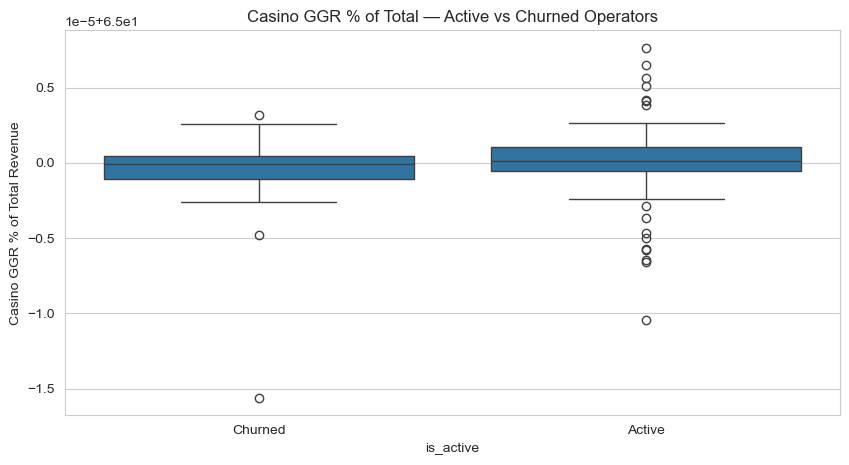

In [31]:
# Visualize
sns.boxplot(data=avg_split, x='is_active', y='casino_pct')
plt.xticks([0, 1], ['Churned', 'Active'])
plt.title('Casino GGR % of Total — Active vs Churned Operators')
plt.ylabel('Casino GGR % of Total Revenue')
plt.show()

### Q11. `bonus_cost_usd` as % of GGR — are churned operators burning more on bonuses relative to revenue?

In [32]:
revenue['bonus_pct_of_ggr'] = revenue['bonus_cost_usd'] / revenue['total_ggr_usd'] * 100

avg_bonus_pct = revenue.groupby('operator_id')['bonus_pct_of_ggr'].mean().reset_index()
avg_bonus_pct = avg_bonus_pct.merge(operators[['operator_id', 'is_active']], on='operator_id')

avg_bonus_pct.groupby('is_active')['bonus_pct_of_ggr'].describe()[['mean', '50%', 'std']]

,mean,50%,std
is_active,,,
0,6.971364,6.755601,0.817215
1,7.025856,7.041317,0.441995


In [33]:
# Load all datasets
operators = pd.read_csv('operator_accounts.csv', parse_dates=['join_date', 'churn_date'])
revenue   = pd.read_csv('operator_revenue_monthly.csv')
sessions  = pd.read_csv('player_sessions.csv', parse_dates=['session_start'])
payments  = pd.read_csv('payments_transactions.csv', parse_dates=['transaction_date'])
bets      = pd.read_csv('sportsbook_bets.csv', parse_dates=['bet_date'])
games     = pd.read_csv('game_catalog.csv', parse_dates=['launch_date'])

print("operators:", operators.shape)
print("revenue:  ", revenue.shape)
print("sessions: ", sessions.shape)
print("payments: ", payments.shape)
print("bets:     ", bets.shape)
print("games:    ", games.shape)

operators: (80, 14)
revenue:   (1420, 13)
sessions:  (50000, 15)
payments:  (25000, 13)
bets:      (20000, 15)
games:     (8000, 13)


In [34]:
# Recompute tenure_months on operators
reference_date = pd.Timestamp('2024-12-31')
operators['end_date'] = operators['churn_date'].fillna(reference_date)
operators['tenure_months'] = (
    (operators['end_date'] - operators['join_date']) / pd.Timedelta(days=30)
).round(1)

# Recompute casino_pct, sports_pct, bonus_pct_of_ggr on revenue
revenue['casino_pct'] = revenue['casino_ggr_usd'] / revenue['total_ggr_usd'] * 100
revenue['sports_pct'] = revenue['sports_ggr_usd'] / revenue['total_ggr_usd'] * 100
revenue['bonus_pct_of_ggr'] = revenue['bonus_cost_usd'] / revenue['total_ggr_usd'] * 100

print("Derived columns added.")

Derived columns added.


In [35]:
# Quick preview of player_sessions
sessions.head()

,session_id,operator_id,player_id,session_start,duration_min,game_type,provider,country,device,bets_placed,avg_stake_usd,total_wagered_usd,ggr_usd,deposit_made,bonus_used
0,SES0000001,OP0014,PLR004741,2024-02-11 07:13:15,81,Slots,Evolution,PH,Desktop,37,101.76,3765.12,878.29,0,1
1,SES0000002,OP0039,PLR006966,2023-12-22 19:23:47,32,Virtual Sports,Playtech,ZA,Mobile,51,147.58,7526.58,1227.24,0,1
2,SES0000003,OP0054,PLR006737,2024-04-15 05:34:12,29,Crash,Playtech,DE,Desktop,28,144.14,4035.92,420.68,0,1
3,SES0000004,OP0069,PLR006346,2023-11-27 08:56:17,121,Crash,Evolution,AU,Desktop,28,123.95,3470.60,301.91,1,0
4,SES0000005,OP0079,PLR005474,2024-05-14 07:43:22,88,Crash,Play n GO,AU,Mobile,2,74.40,148.80,-2.98,0,0


---
##  Player-Level Engagement (`player_sessions.csv`)

### Q12. Aggregate engagement metrics per operator

We aggregate `duration_min`, `bets_placed`, and `total_wagered_usd` per operator,
then compare churned vs. active operators.

In [37]:
# Aggregate session-level metrics to operator level
session_agg = sessions.groupby('operator_id').agg(
    avg_session_duration=('duration_min', 'mean'),
    avg_bets_placed=('bets_placed', 'mean'),
    avg_wagered_usd=('total_wagered_usd', 'mean'),
    total_sessions=('session_id', 'count'),
    deposit_rate=('deposit_made', 'mean'),
    bonus_usage_rate=('bonus_used', 'mean')
).reset_index()

session_agg.head()

,operator_id,avg_session_duration,avg_bets_placed,avg_wagered_usd,total_sessions,deposit_rate,bonus_usage_rate
0,OP0001,90.884914,31.239502,2473.588289,643,0.228616,0.311042
1,OP0002,88.731298,29.909924,2257.676031,655,0.242748,0.311450
2,OP0003,87.250417,28.913189,2104.076511,599,0.282137,0.260434
3,OP0004,93.364261,30.359107,2247.890206,582,0.261168,0.321306
4,OP0005,91.844444,28.831746,2026.054524,630,0.257143,0.306349


In [38]:
# Merge with operator status
session_agg = session_agg.merge(operators[['operator_id', 'is_active']], on='operator_id')

# Compare: Active vs Churned
session_agg.groupby('is_active')[
    ['avg_session_duration', 'avg_bets_placed', 'avg_wagered_usd', 'total_sessions']
].mean().round(2)

,avg_session_duration,avg_bets_placed,avg_wagered_usd,total_sessions
is_active,,,,
0,91.45,30.66,2324.73,632.44
1,90.69,30.56,2316.66,623.14


C:\Users\hp\AppData\Local\Temp\ipykernel_5652\1262676035.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Churned', 'Active'])
C:\Users\hp\AppData\Local\Temp\ipykernel_5652\1262676035.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Churned', 'Active'])


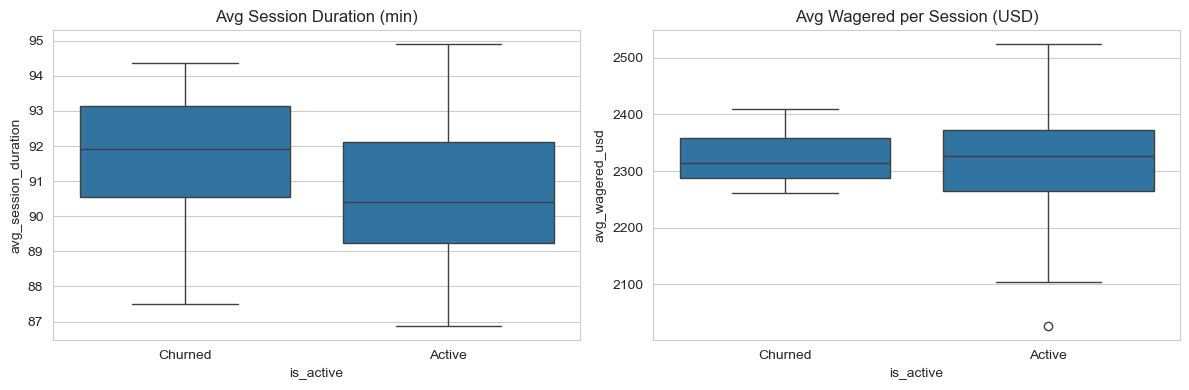

In [39]:
# Visualize: avg session duration & avg wagered amount
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=session_agg, x='is_active', y='avg_session_duration', ax=axes[0])
axes[0].set_xticklabels(['Churned', 'Active'])
axes[0].set_title('Avg Session Duration (min)')

sns.boxplot(data=session_agg, x='is_active', y='avg_wagered_usd', ax=axes[1])
axes[1].set_xticklabels(['Churned', 'Active'])
axes[1].set_title('Avg Wagered per Session (USD)')

plt.tight_layout()
plt.show()

###  `device` mix per operator — mobile-heavy vs desktop-heavy, any churn correlation?

In [41]:
# Calculate % of sessions by device type, per operator
device_mix = sessions.groupby(['operator_id', 'device']).size().unstack(fill_value=0)
device_mix_pct = device_mix.div(device_mix.sum(axis=1), axis=0) * 100
device_mix_pct = device_mix_pct.reset_index()

device_mix_pct.head()

device,operator_id,Desktop,Mobile,Tablet
0,OP0001,31.415241,63.297045,5.287714
1,OP0002,31.450382,64.427481,4.122137
2,OP0003,31.552588,64.774624,3.672788
3,OP0004,29.037801,64.776632,6.185567
4,OP0005,30.000000,64.920635,5.079365


In [42]:
# Merge with operator status and compare mobile %
device_mix_pct = device_mix_pct.merge(operators[['operator_id', 'is_active']], on='operator_id')

device_mix_pct.groupby('is_active')['Mobile'].describe()[['mean', '50%', 'std']]

,mean,50%,std
is_active,,,
0,65.640507,65.888506,2.408774
1,64.957847,65.079148,1.999719


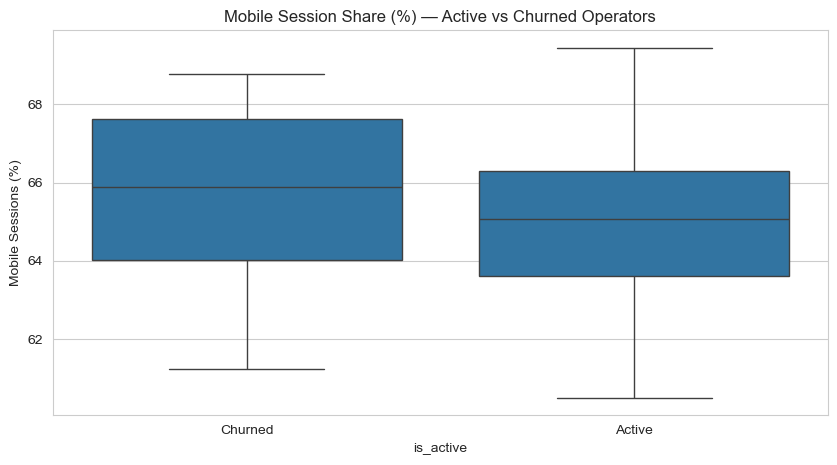

In [43]:
# Visualize
sns.boxplot(data=device_mix_pct, x='is_active', y='Mobile')
plt.xticks([0, 1], ['Churned', 'Active'])
plt.title('Mobile Session Share (%) — Active vs Churned Operators')
plt.ylabel('Mobile Sessions (%)')
plt.show()

###  `bonus_used` rate per operator — heavy bonus dependency as a churn signal

In [44]:
# Already calculated as bonus_usage_rate in session_agg
session_agg.groupby('is_active')['bonus_usage_rate'].describe()[['mean', '50%', 'std']]

,mean,50%,std
is_active,,,
0,0.304395,0.303732,0.017107
1,0.298582,0.299919,0.016087


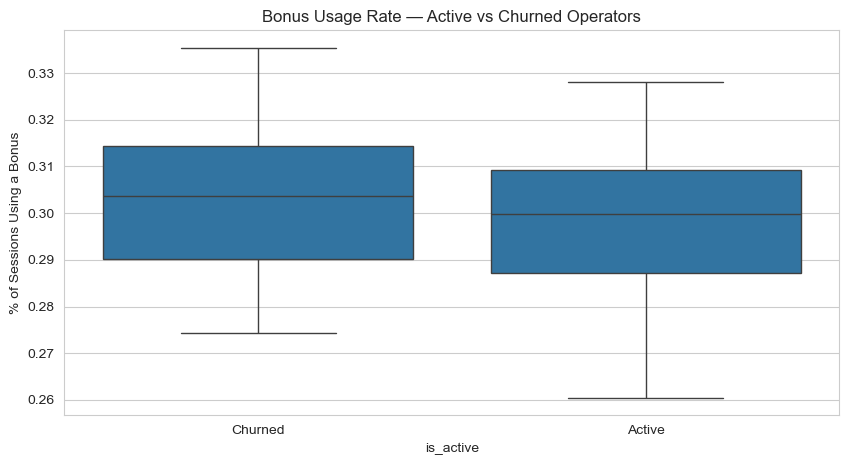

In [45]:
# Visualize
sns.boxplot(data=session_agg, x='is_active', y='bonus_usage_rate')
plt.xticks([0, 1], ['Churned', 'Active'])
plt.title('Bonus Usage Rate — Active vs Churned Operators')
plt.ylabel('% of Sessions Using a Bonus')
plt.show()

### Q15. `deposit_made` rate per session — conversion health indicator

In [46]:
# Already calculated as deposit_rate in session_agg
session_agg.groupby('is_active')['deposit_rate'].describe()[['mean', '50%', 'std']]

,mean,50%,std
is_active,,,
0,0.250368,0.247996,0.015775
1,0.253270,0.252536,0.021039


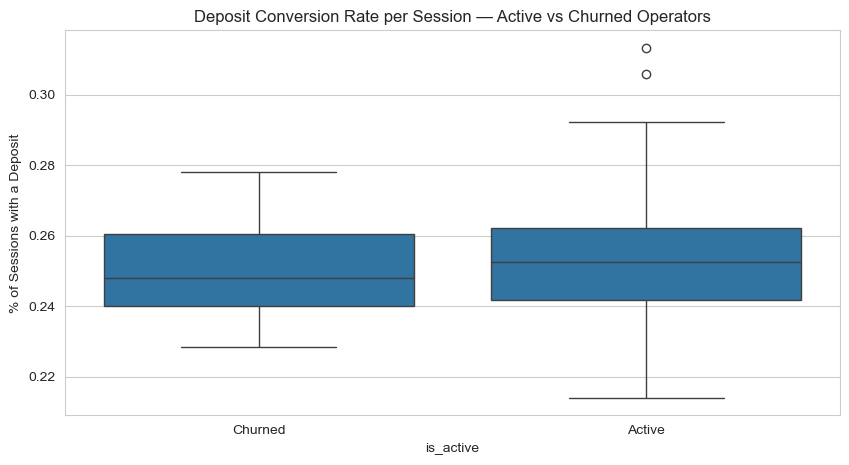

In [47]:
# Visualize
sns.boxplot(data=session_agg, x='is_active', y='deposit_rate')
plt.xticks([0, 1], ['Churned', 'Active'])
plt.title('Deposit Conversion Rate per Session — Active vs Churned Operators')
plt.ylabel('% of Sessions with a Deposit')
plt.show()

### Q16. Failed/Reversed transaction rate per operator — payment friction as a churn driver

In [48]:
# Flag failed or reversed transactions
payments['is_failed'] = payments['status'].isin(['Failed', 'Reversed']).astype(int)

# Aggregate to operator level
payment_agg = payments.groupby('operator_id').agg(
    total_transactions=('transaction_id', 'count'),
    failed_txn_rate=('is_failed', 'mean'),
    avg_processing_time_sec=('processing_time_sec', 'mean'),
    avg_fee_usd=('fee_usd', 'mean'),
    first_deposit_count=('is_first_deposit', 'sum')
).reset_index()

payment_agg.head()

,operator_id,total_transactions,failed_txn_rate,avg_processing_time_sec,avg_fee_usd,first_deposit_count
0,OP0001,301,0.139535,3284.966245,43.552591,41
1,OP0002,300,0.173333,3776.663677,41.949567,41
2,OP0003,315,0.158730,3472.589744,43.049968,48
3,OP0004,333,0.108108,3641.719557,45.444144,41
4,OP0005,317,0.123028,3280.044355,42.929464,53


In [49]:
# Merge with operator status
payment_agg = payment_agg.merge(operators[['operator_id', 'is_active']], on='operator_id')

# Compare failed transaction rate
payment_agg.groupby('is_active')['failed_txn_rate'].describe()[['mean', '50%', 'std']]

,mean,50%,std
is_active,,,
0,0.135727,0.133546,0.015365
1,0.142875,0.141760,0.020661


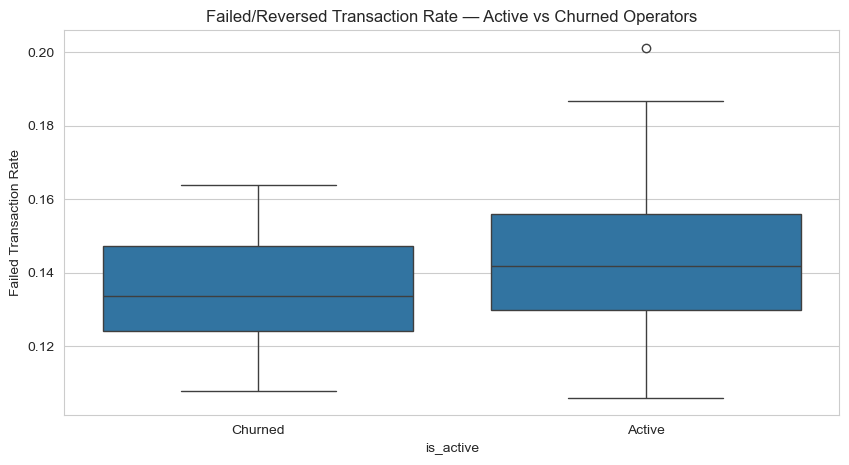

In [50]:
# Visualize
sns.boxplot(data=payment_agg, x='is_active', y='failed_txn_rate')
plt.xticks([0, 1], ['Churned', 'Active'])
plt.title('Failed/Reversed Transaction Rate — Active vs Churned Operators')
plt.ylabel('Failed Transaction Rate')
plt.show()

In [51]:
payment_agg.groupby('is_active')['avg_processing_time_sec'].describe()[['mean', '50%', 'std']]

,mean,50%,std
is_active,,,
0,3576.453578,3579.691032,125.432639
1,3574.204272,3579.359592,147.031600


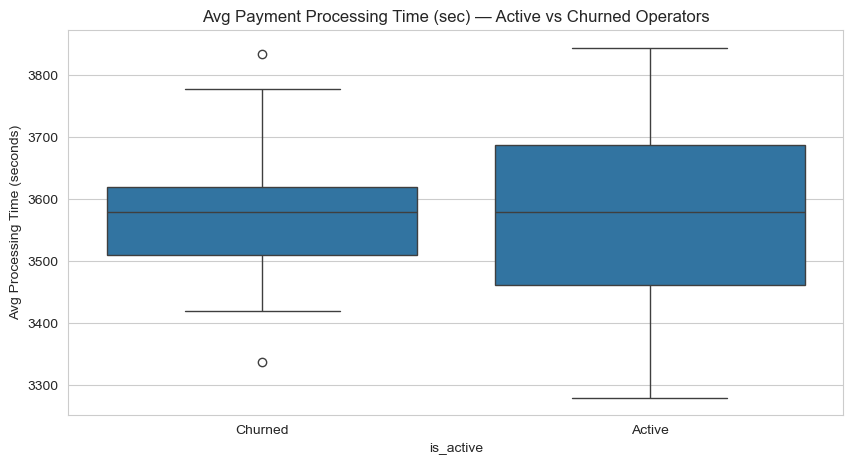

In [52]:
# Visualize
sns.boxplot(data=payment_agg, x='is_active', y='avg_processing_time_sec')
plt.xticks([0, 1], ['Churned', 'Active'])
plt.title('Avg Payment Processing Time (sec) — Active vs Churned Operators')
plt.ylabel('Avg Processing Time (seconds)')
plt.show()

### Q18. `is_first_deposit` count over time per operator — is new player acquisition slowing down?

In [53]:
# Add a year-month column for trend analysis
payments['txn_month'] = payments['transaction_date'].dt.to_period('M').astype(str)

# Count first deposits per operator per month
first_deposits_trend = payments[payments['is_first_deposit'] == 1].groupby(
    ['operator_id', 'txn_month']
).size().reset_index(name='first_deposits')

first_deposits_trend.head()

,operator_id,txn_month,first_deposits
0,OP0001,2023-01,2
1,OP0001,2023-04,2
2,OP0001,2023-05,2
3,OP0001,2023-08,4
4,OP0001,2023-09,2


In [54]:
# For each churned operator, compare first-deposit volume in first 3 months vs last 3 months
results_fd = []
for op_id in operators[operators['is_active'] == 0]['operator_id']:
    op_fd = first_deposits_trend[first_deposits_trend['operator_id'] == op_id].sort_values('txn_month')
    if len(op_fd) < 4:
        continue
    first_3 = op_fd.head(3)['first_deposits'].mean()
    last_3 = op_fd.tail(3)['first_deposits'].mean()
    results_fd.append({'operator_id': op_id, 'first_3m_avg': first_3, 'last_3m_avg': last_3})

fd_trend_df = pd.DataFrame(results_fd)
fd_trend_df['pct_change'] = (
    (fd_trend_df['last_3m_avg'] - fd_trend_df['first_3m_avg']) / fd_trend_df['first_3m_avg']
) * 100

fd_trend_df.head(10)

,operator_id,first_3m_avg,last_3m_avg,pct_change
0,OP0007,2.333333,2.666667,14.285714
1,OP0008,3.000000,1.666667,-44.444444
2,OP0011,1.333333,1.333333,0.000000
3,OP0012,2.666667,2.000000,-25.000000
4,OP0018,3.666667,3.333333,-9.090909
5,OP0020,2.666667,3.000000,12.500000
6,OP0021,2.000000,1.666667,-16.666667
7,OP0031,2.333333,2.000000,-14.285714
8,OP0039,3.333333,2.333333,-30.000000
9,OP0040,1.666667,2.000000,20.000000


In [55]:
declining_fd = (fd_trend_df['pct_change'] < 0).sum()
total_fd = len(fd_trend_df)
print(f"{declining_fd} out of {total_fd} churned operators "
      f"({declining_fd/total_fd*100:.1f}%) show declining new-player acquisition")

8 out of 16 churned operators (50.0%) show declining new-player acquisition


### Q19. Currency / payment method mix — any patterns by region tied to churn?

In [59]:
# Most common payment method per operator
payment_method_mix = payments.groupby(['operator_id', 'payment_method']).size().reset_index(name='count')
top_method = payment_method_mix.sort_values('count', ascending=False).drop_duplicates('operator_id')
top_method = top_method.merge(operators[['operator_id', 'is_active', 'country']], on='operator_id')

top_method.head()

,operator_id,payment_method,count,is_active,country
0,OP0070,Card,90,1,GB
1,OP0010,Crypto,88,1,CA
2,OP0004,Card,88,1,IN
3,OP0013,E-Wallet,83,1,DE
4,OP0037,Mobile Money,83,1,NG


In [60]:
# Cross-tab: top payment method vs churn status
pd.crosstab(top_method['payment_method'], top_method['is_active'], normalize='index') \
  .rename(columns={0: 'Churned', 1: 'Active'}).round(2)

is_active,Churned,Active
payment_method,,
Bank Transfer,0.13,0.87
Card,0.40,0.60
Crypto,0.12,0.88
E-Wallet,0.07,0.93
Mobile Money,0.30,0.70


### Q20. `operator_margin_usd` trend per operator — is the sportsbook profitable for them?

In [61]:
# Aggregate bet-level metrics to operator level
bet_agg = bets.groupby('operator_id').agg(
    total_bets=('bet_id', 'count'),
    avg_stake_usd=('stake_usd', 'mean'),
    avg_margin_usd=('operator_margin_usd', 'mean'),
    total_margin_usd=('operator_margin_usd', 'sum'),
    live_bet_rate=('live_bet', 'mean')
).reset_index()

bet_agg.head()

,operator_id,total_bets,avg_stake_usd,avg_margin_usd,total_margin_usd,live_bet_rate
0,OP0001,257,261.427938,-369.263658,-94900.76,0.428016
1,OP0002,264,245.445758,-411.084848,-108526.40,0.382576
2,OP0003,233,250.838197,-360.473605,-83990.35,0.433476
3,OP0004,271,244.922657,-266.757897,-72291.39,0.413284
4,OP0005,234,243.023632,-463.030256,-108349.08,0.371795


In [62]:
# Merge with operator status
bet_agg = bet_agg.merge(operators[['operator_id', 'is_active']], on='operator_id')

# Compare avg margin per bet: Active vs Churned
bet_agg.groupby('is_active')['avg_margin_usd'].describe()[['mean', '50%', 'std']]

,mean,50%,std
is_active,,,
0,-372.033918,-365.991961,60.781777
1,-368.537027,-368.164998,70.006940


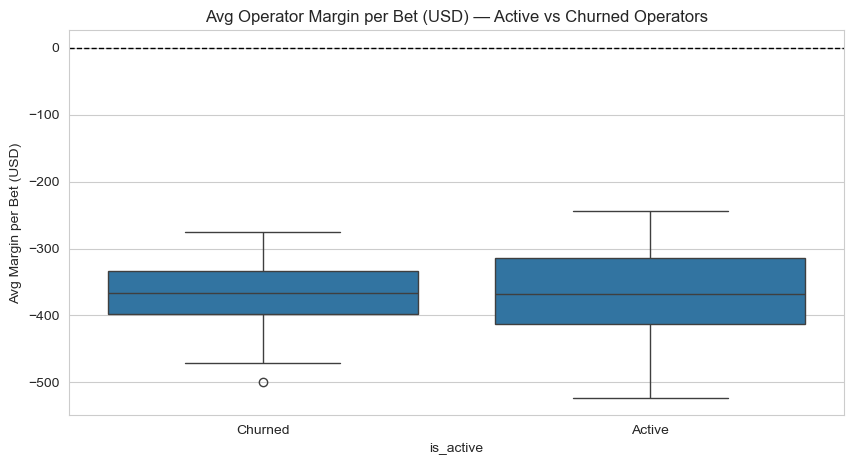

In [64]:
# Visualize
sns.boxplot(data=bet_agg, x='is_active', y='avg_margin_usd')
plt.xticks([0, 1], ['Churned', 'Active'])
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Avg Operator Margin per Bet (USD) — Active vs Churned Operators')
plt.ylabel('Avg Margin per Bet (USD)')
plt.show()

### Q21. `live_bet` ratio — live betting adoption as an engagement/modernity signal

In [65]:
bet_agg.groupby('is_active')['live_bet_rate'].describe()[['mean', '50%', 'std']]

,mean,50%,std
is_active,,,
0,0.404012,0.408518,0.035326
1,0.395625,0.396033,0.031432


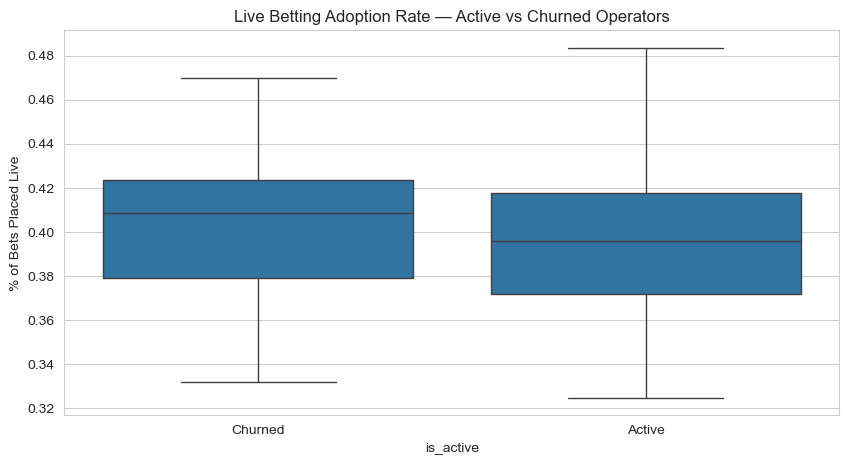

In [66]:
# Visualize
sns.boxplot(data=bet_agg, x='is_active', y='live_bet_rate')
plt.xticks([0, 1], ['Churned', 'Active'])
plt.title('Live Betting Adoption Rate — Active vs Churned Operators')
plt.ylabel('% of Bets Placed Live')
plt.show()

In [67]:
# Add year-month column
bets['bet_month'] = bets['bet_date'].dt.to_period('M').astype(str)

# Count bets per operator per month
bet_volume_trend = bets.groupby(['operator_id', 'bet_month']).size().reset_index(name='bet_count')

# For churned operators, compare first 3 months vs last 3 months
results_bv = []
for op_id in operators[operators['is_active'] == 0]['operator_id']:
    op_bv = bet_volume_trend[bet_volume_trend['operator_id'] == op_id].sort_values('bet_month')
    if len(op_bv) < 4:
        continue
    first_3 = op_bv.head(3)['bet_count'].mean()
    last_3 = op_bv.tail(3)['bet_count'].mean()
    results_bv.append({'operator_id': op_id, 'first_3m_avg': first_3, 'last_3m_avg': last_3})

bv_trend_df = pd.DataFrame(results_bv)
bv_trend_df['pct_change'] = (
    (bv_trend_df['last_3m_avg'] - bv_trend_df['first_3m_avg']) / bv_trend_df['first_3m_avg']
) * 100

bv_trend_df.head(10)

,operator_id,first_3m_avg,last_3m_avg,pct_change
0,OP0007,12.000000,12.333333,2.777778
1,OP0008,11.333333,9.666667,-14.705882
2,OP0011,12.333333,11.000000,-10.810811
3,OP0012,10.666667,11.333333,6.250000
4,OP0018,11.000000,9.666667,-12.121212
5,OP0020,10.333333,9.333333,-9.677419
6,OP0021,12.000000,12.666667,5.555556
7,OP0031,8.333333,10.666667,28.000000
8,OP0039,12.666667,6.666667,-47.368421
9,OP0040,10.666667,12.666667,18.750000


In [68]:
declining_bv = (bv_trend_df['pct_change'] < 0).sum()
total_bv = len(bv_trend_df)
print(f"{declining_bv} out of {total_bv} churned operators "
      f"({declining_bv/total_bv*100:.1f}%) show declining bet volume over time")

7 out of 16 churned operators (43.8%) show declining bet volume over time


### Q23. Which `provider`s and `game_type`s generate the most GGR?

In [69]:
# Total GGR by provider
ggr_by_provider = sessions.groupby('provider')['ggr_usd'].sum().sort_values(ascending=False)
ggr_by_provider

provider
Spribe            632908.18
Pragmatic Play    613426.89
Play n GO         606736.24
NetEnt            585011.68
BGaming           583912.55
Microgaming       576169.98
Relax Gaming      575391.29
Evolution         574082.90
Hacksaw           546271.88
Playtech          540620.76
Name: ggr_usd, dtype: float64

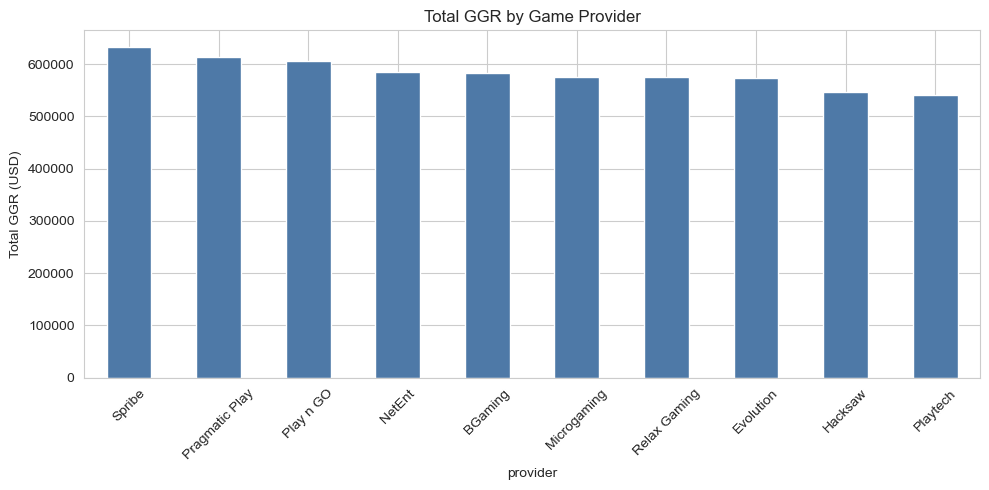

In [70]:
# Visualize
ggr_by_provider.plot(kind='bar', color='#4E79A7')
plt.title('Total GGR by Game Provider')
plt.ylabel('Total GGR (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
# Total GGR by game_type
ggr_by_game_type = sessions.groupby('game_type')['ggr_usd'].sum().sort_values(ascending=False)
ggr_by_game_type

game_type
Slots             1215039.83
Virtual Sports    1193192.71
Table Games       1184199.73
Crash             1140459.80
Live Casino       1101640.28
Name: ggr_usd, dtype: float64

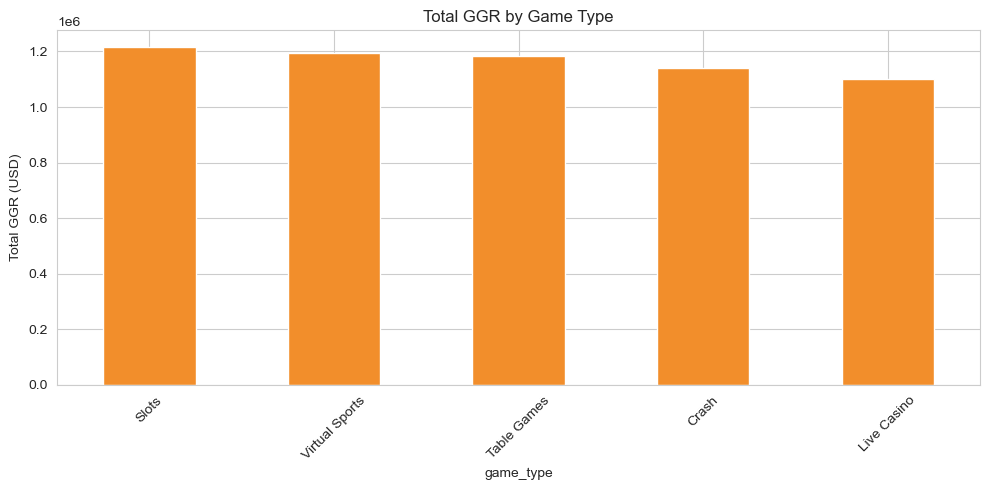

In [72]:
# Visualize
ggr_by_game_type.plot(kind='bar', color='#F28E2B')
plt.title('Total GGR by Game Type')
plt.ylabel('Total GGR (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
### Q24. RTP and volatility — do these correlate with engagement?

In [73]:
# Merge sessions with game_catalog on provider + game_type to get avg RTP/volatility context
# (Note: catalog is at game level, sessions are at provider/game_type level —
#  we approximate by averaging catalog RTP per provider+game_type combination)

catalog_avg = games.groupby(['provider', 'game_type']).agg(
    avg_rtp=('rtp_pct', 'mean'),
    pct_high_volatility=('volatility', lambda x: (x == 'High').mean())
).reset_index()

catalog_avg.head()

,provider,game_type,avg_rtp,pct_high_volatility
0,BGaming,Crash,95.000621,0.347826
1,BGaming,Live Casino,97.701648,0.346154
2,BGaming,Slots,95.281039,0.376623
3,BGaming,Table Games,95.289504,0.319149
4,BGaming,Virtual Sports,95.277041,0.278107


In [75]:
# Merge with session GGR data
session_provider_type = sessions.groupby(['provider', 'game_type']).agg(
    total_ggr=('ggr_usd', 'sum'),
    avg_session_duration=('duration_min', 'mean'),
    session_count=('session_id', 'count')
).reset_index()

merged_catalog = session_provider_type.merge(catalog_avg, on=['provider', 'game_type'])
merged_catalog.head(10)

,provider,game_type,total_ggr,avg_session_duration,session_count,avg_rtp,pct_high_volatility
0,BGaming,Crash,122705.91,93.160149,1074,95.000621,0.347826
1,BGaming,Live Casino,113762.62,89.201417,988,97.701648,0.346154
2,BGaming,Slots,100277.88,88.473526,1001,95.281039,0.376623
3,BGaming,Table Games,110705.07,93.889669,997,95.289504,0.319149
4,BGaming,Virtual Sports,136461.07,92.514371,1009,95.277041,0.278107
5,Evolution,Crash,101741.64,89.350823,972,95.426667,0.333333
6,Evolution,Live Casino,114276.64,90.917918,999,97.701905,0.291667
7,Evolution,Slots,118733.65,90.967456,1014,95.284589,0.321918
8,Evolution,Table Games,117835.68,90.736585,1025,94.989262,0.275168
9,Evolution,Virtual Sports,121495.29,89.747544,1018,95.111479,0.272189


In [76]:
# Correlation: avg RTP vs total GGR, and volatility vs session duration
print("Correlation (avg_rtp vs total_ggr):",
      round(merged_catalog['avg_rtp'].corr(merged_catalog['total_ggr']), 3))

print("Correlation (pct_high_volatility vs avg_session_duration):",
      round(merged_catalog['pct_high_volatility'].corr(merged_catalog['avg_session_duration']), 3))

Correlation (avg_rtp vs total_ggr): -0.289
Correlation (pct_high_volatility vs avg_session_duration): -0.083


### Q25. % of catalog that's `is_active = 1` and `mobile_ready = 1` — are stale/non-mobile catalogs underperforming?

In [77]:
# Overall catalog health stats
print(f"Active games in catalog: {games['is_active'].mean()*100:.1f}%")
print(f"Mobile-ready games:      {games['mobile_ready'].mean()*100:.1f}%")
print(f"Games with bonus rounds: {games['has_bonus_round'].mean()*100:.1f}%")

Active games in catalog: 90.5%
Mobile-ready games:      84.8%
Games with bonus rounds: 60.6%


In [78]:
# Catalog health by provider
catalog_health = games.groupby('provider').agg(
    total_games=('game_id', 'count'),
    pct_active=('is_active', 'mean'),
    pct_mobile_ready=('mobile_ready', 'mean')
).round(3)

catalog_health.sort_values('pct_mobile_ready', ascending=False)

,total_games,pct_active,pct_mobile_ready
provider,,,
Evolution,800,0.896,0.871
Play n GO,785,0.912,0.857
Spribe,748,0.912,0.857
BGaming,807,0.902,0.855
Playtech,796,0.901,0.853
Microgaming,830,0.900,0.849
Hacksaw,780,0.917,0.840
Pragmatic Play,824,0.903,0.839
NetEnt,817,0.913,0.831


---
## Section 7: Master Churn Table

Now we combine all the operator-level aggregates built in Sections 1–5 into ONE table —
**one row per operator** — ready for visual comparison (boxplots) and, eventually, modeling.

### Step 1: Recompute revenue trend features (from Section 2) cleanly as a function

In [79]:
def compute_trend(df, op_id, value_col, id_col='operator_id', time_col='month'):
    """Returns % change between first 3 and last 3 periods for a given operator."""
    sub = df[df[id_col] == op_id].sort_values(time_col)
    if len(sub) < 4:
        return np.nan
    first_3 = sub.head(3)[value_col].mean()
    last_3 = sub.tail(3)[value_col].mean()
    if first_3 == 0 or pd.isna(first_3):
        return np.nan
    return ((last_3 - first_3) / first_3) * 100

# Apply to all operators for GGR and active_players trend
all_op_ids = operators['operator_id'].tolist()

trend_rows = []
for op_id in all_op_ids:
    trend_rows.append({
        'operator_id': op_id,
        'ggr_trend_pct': compute_trend(revenue, op_id, 'total_ggr_usd'),
        'active_players_trend_pct': compute_trend(revenue, op_id, 'active_players')
    })

trend_df = pd.DataFrame(trend_rows)
trend_df.head()

,operator_id,ggr_trend_pct,active_players_trend_pct
0,OP0001,11.969267,-5.914186
1,OP0002,16.532502,-37.142857
2,OP0003,-17.019662,4.996530
3,OP0004,-6.938939,12.050360
4,OP0005,-2.814758,-48.246319


### Step 2: Average revenue-level features per operator (overall, not just trend)

In [80]:
revenue_summary = revenue.groupby('operator_id').agg(
    avg_total_ggr=('total_ggr_usd', 'mean'),
    avg_net_software_revenue=('net_software_revenue_usd', 'mean'),
    avg_active_players=('active_players', 'mean'),
    avg_bonus_cost_pct=('bonus_pct_of_ggr', 'mean'),
    avg_casino_pct=('casino_pct', 'mean')
).reset_index()

revenue_summary.head()

,operator_id,avg_total_ggr,avg_net_software_revenue,avg_active_players,avg_bonus_cost_pct,avg_casino_pct
0,OP0001,11027.162000,1948.448667,806.866667,6.219560,65.000008
1,OP0002,9278.100556,1561.398889,847.500000,7.705448,65.000001
2,OP0003,27069.130625,4508.070625,880.125000,6.978755,65.000000
3,OP0004,29859.583529,5198.647059,735.235294,6.318967,65.000000
4,OP0005,19422.219167,3189.905833,750.916667,7.448394,65.000004


In [81]:
# Start with operator profile
master = operators[[
    'operator_id', 'plan_tier', 'country', 'platform_type',
    'monthly_fee_usd', 'tenure_months', 'games_enabled',
    'sports_markets_enabled', 'payment_methods_count', 'is_active'
]].copy()

# Merge revenue summary + trends
master = master.merge(revenue_summary, on='operator_id', how='left')
master = master.merge(trend_df, on='operator_id', how='left')

# Merge engagement (session_agg) — drop is_active to avoid duplicate column
master = master.merge(
    session_agg.drop(columns='is_active'),
    on='operator_id', how='left'
)

# Merge payments
master = master.merge(
    payment_agg.drop(columns='is_active'),
    on='operator_id', how='left'
)

# Merge sportsbook
master = master.merge(
    bet_agg.drop(columns='is_active'),
    on='operator_id', how='left'
)

print("Master table shape:", master.shape)
master.head()

Master table shape: (80, 33)


,operator_id,plan_tier,country,platform_type,monthly_fee_usd,tenure_months,games_enabled,sports_markets_enabled,payment_methods_count,is_active,avg_total_ggr,avg_net_software_revenue,avg_active_players,avg_bonus_cost_pct,avg_casino_pct,ggr_trend_pct,active_players_trend_pct,avg_session_duration,avg_bets_placed,avg_wagered_usd,total_sessions,deposit_rate,bonus_usage_rate,total_transactions,failed_txn_rate,avg_processing_time_sec,avg_fee_usd,first_deposit_count,total_bets,avg_stake_usd,avg_margin_usd,total_margin_usd,live_bet_rate
0,OP0001,Starter,AU,Casino,2500,14.7,5743,0,7,1,11027.162000,1948.448667,806.866667,6.219560,65.000008,11.969267,-5.914186,90.884914,31.239502,2473.588289,643,0.228616,0.311042,301,0.139535,3284.966245,43.552591,41,257,261.427938,-369.263658,-94900.76,0.428016
1,OP0002,Starter,NG,Casino,2500,17.9,2105,0,6,1,9278.100556,1561.398889,847.500000,7.705448,65.000001,16.532502,-37.142857,88.731298,29.909924,2257.676031,655,0.242748,0.311450,300,0.173333,3776.663677,41.949567,41,264,245.445758,-411.084848,-108526.40,0.382576
2,OP0003,Starter,CA,Both,2500,16.0,2005,0,5,1,27069.130625,4508.070625,880.125000,6.978755,65.000000,-17.019662,4.996530,87.250417,28.913189,2104.076511,599,0.282137,0.260434,315,0.158730,3472.589744,43.049968,48,233,250.838197,-360.473605,-83990.35,0.433476
3,OP0004,Starter,IN,Casino,2500,16.4,2987,0,4,1,29859.583529,5198.647059,735.235294,6.318967,65.000000,-6.938939,12.050360,93.364261,30.359107,2247.890206,582,0.261168,0.321306,333,0.108108,3641.719557,45.444144,41,271,244.922657,-266.757897,-72291.39,0.413284
4,OP0005,Starter,ZA,Sportsbook,2500,31.2,3140,0,8,1,19422.219167,3189.905833,750.916667,7.448394,65.000004,-2.814758,-48.246319,91.844444,28.831746,2026.054524,630,0.257143,0.306349,317,0.123028,3280.044355,42.929464,53,234,243.023632,-463.030256,-108349.08,0.371795


In [82]:
# Check for missing values
master.isnull().sum()

operator_id                 0
plan_tier                   0
country                     0
platform_type               0
monthly_fee_usd             0
tenure_months               0
games_enabled               0
sports_markets_enabled      0
payment_methods_count       0
is_active                   0
avg_total_ggr               1
avg_net_software_revenue    1
avg_active_players          1
avg_bonus_cost_pct          1
avg_casino_pct              1
ggr_trend_pct               2
active_players_trend_pct    2
avg_session_duration        0
avg_bets_placed             0
avg_wagered_usd             0
total_sessions              0
deposit_rate                0
bonus_usage_rate            0
total_transactions          0
failed_txn_rate             0
avg_processing_time_sec     0
avg_fee_usd                 0
first_deposit_count         0
total_bets                  0
avg_stake_usd               0
avg_margin_usd              0
total_margin_usd            0
live_bet_rate               0
dtype: int

In [83]:
master.to_csv('master_churn_table.csv', index=False)
print("Saved master_churn_table.csv with", master.shape[0], "rows and", master.shape[1], "columns")

Saved master_churn_table.csv with 80 rows and 33 columns


C:\Users\hp\AppData\Local\Temp\ipykernel_5652\4119941028.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Churned', 'Active'])
C:\Users\hp\AppData\Local\Temp\ipykernel_5652\4119941028.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Churned', 'Active'])
C:\Users\hp\AppData\Local\Temp\ipykernel_5652\4119941028.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Churned', 'Active'])
C:\Users\hp\AppData\Local\Temp\ipykernel_5652\4119941028.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Churned', 'Active'])
C:\Users\hp\AppData\Local\Temp\ipykernel_5652\4119941028

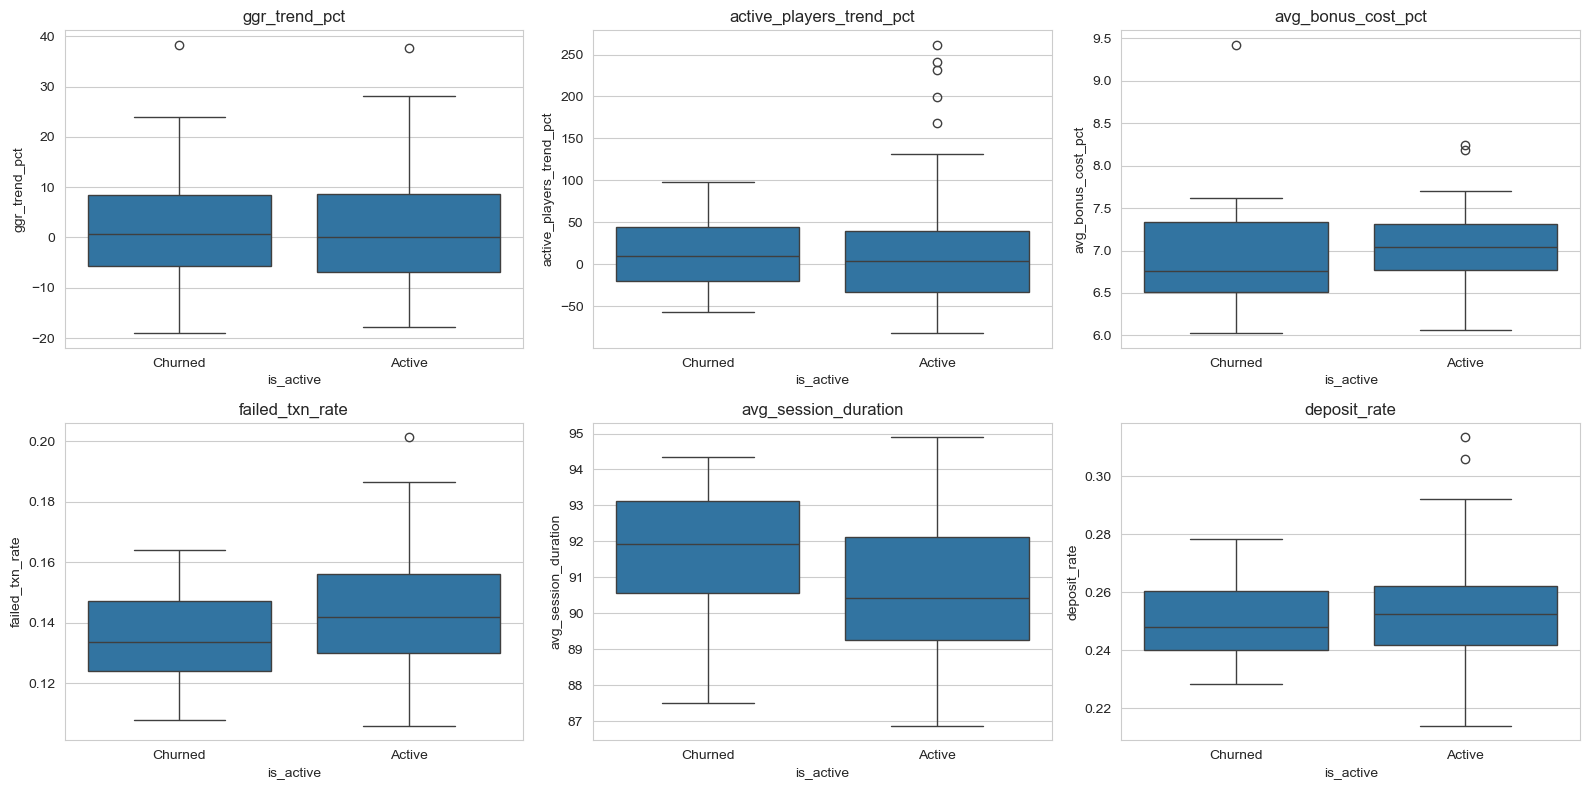

In [84]:
# Pick a few of the most important features and visualize side-by-side
key_features = [
    'ggr_trend_pct', 'active_players_trend_pct', 'avg_bonus_cost_pct',
    'failed_txn_rate', 'avg_session_duration', 'deposit_rate'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, key_features):
    sns.boxplot(data=master, x='is_active', y=col, ax=ax)
    ax.set_xticklabels(['Churned', 'Active'])
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [85]:
# Correlation of numeric features with churn (is_active)
numeric_cols = master.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('is_active')

corr_with_churn = master[numeric_cols + ['is_active']].corr()['is_active'].drop('is_active')
corr_with_churn.sort_values(key=abs, ascending=False)

tenure_months               0.337408
first_deposit_count         0.282346
payment_methods_count      -0.244278
total_transactions          0.235803
avg_session_duration       -0.151854
total_sessions             -0.147100
failed_txn_rate             0.145050
bonus_usage_rate           -0.143089
avg_casino_pct              0.122385
live_bet_rate              -0.104882
sports_markets_enabled      0.067553
deposit_rate                0.058293
avg_bets_placed            -0.055555
avg_fee_usd                 0.054864
avg_wagered_usd            -0.041340
avg_bonus_cost_pct          0.040784
avg_active_players          0.040668
ggr_trend_pct              -0.038193
avg_total_ggr               0.028854
active_players_trend_pct    0.027877
monthly_fee_usd            -0.026975
total_bets                  0.025039
avg_net_software_revenue    0.024647
avg_margin_usd              0.020727
games_enabled               0.013397
avg_stake_usd               0.011957
total_margin_usd            0.006688
a

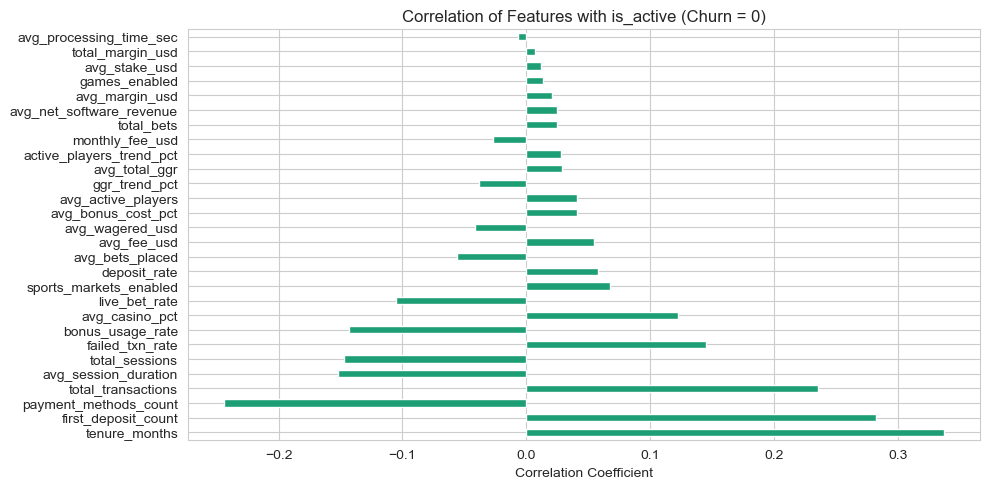

In [86]:
# Visualize correlation
corr_with_churn.sort_values(key=abs, ascending=False).plot(kind='barh', color='#1D9E75')
plt.title('Correlation of Features with is_active (Churn = 0)')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()